In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 102.4 MB/s eta 0:00:00


In [2]:
!nvidia-smi

import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.is_available())

Thu Jun 25 20:55:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Library imports
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pennylane as qp

# Pytorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [4]:
# -----------------------------
# Quantum Hyperparameters
# -----------------------------

image_size = 8

latent_dim = 32

stem_hidden = 16

n_classes = 10

n_qubits = 5
n_a_qubits = 1
q_depth = 6

n_generators = 4

patch_size = 2 ** (n_qubits - n_a_qubits)

assert patch_size * n_generators == image_size * image_size

In [5]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [6]:
class DigitsDataset(Dataset):

    def __init__(self, csv_file, transform=None):

        self.df = pd.read_csv(csv_file)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        image = self.df.iloc[idx, :-1].values.astype(np.float32)

        image = image.reshape(8,8)/16.0

        label = int(self.df.iloc[idx,-1])

        if self.transform:

            image = self.transform(image)

        return image, label

In [7]:
dataset = DigitsDataset(
    "/kaggle/input/datasets/shriram00/digits/optdigits.tra",
    transform=transform
)

In [8]:
batch_size = 16

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

In [9]:
# Quantum simulator
dev = qp.device("lightning.qubit", wires=n_qubits)
# Enable CUDA device if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [10]:
@qp.qnode(dev, diff_method="parameter-shift")
def quantum_circuit(latent, weights, label_bias):
    """
    latent      : (n_qubits,)
    weights     : (q_depth*n_qubits,)
    label_bias  : (q_depth,n_qubits)
    """

    weights = weights.reshape(q_depth, n_qubits)

    # -----------------------------
    # State preparation
    # -----------------------------
    for qubit in range(n_qubits):
        qp.RY(latent[qubit], wires=qubit)

    # -----------------------------
    # Conditional variational circuit
    # -----------------------------
    for layer in range(q_depth):

        for qubit in range(n_qubits):

            qp.RY(
                weights[layer, qubit] +
                label_bias[layer, qubit],
                wires=qubit
            )


        for qubit in range(n_qubits - 1):
            qp.CZ(wires=[qubit, qubit + 1])

    return qp.probs(wires=range(n_qubits))


def partial_measure(latent, weights, label_bias):

    probs = quantum_circuit(
        latent,
        weights,
        label_bias
    )

    probs = probs[: 2 ** (n_qubits - n_a_qubits)]

    probs = probs / probs.sum()

    probs = probs / probs.max()

    return probs

In [11]:
class QuantumPatch(nn.Module):

    def __init__(self):

        super().__init__()

        self.q_params = nn.Parameter(

            0.01*torch.randn(
                q_depth*n_qubits
            )

        )

    def forward(
        self,
        latent,
        label_bias
    ):

        outputs=[]

        for x,b in zip(

            latent,

            label_bias

        ):

            outputs.append(partial_measure(x,self.q_params,b).float())

        return torch.stack(outputs)

In [12]:
class ConditionalQuantumGenerator(nn.Module):

    def __init__(self):

        super().__init__()

        self.bias_network = nn.Sequential(nn.Linear(latent_dim,64),nn.ReLU(),nn.Linear(64,n_generators*q_depth*n_qubits))

        self.label_embedding = nn.Embedding(
            n_classes,
            latent_dim
        )

        self.stem = nn.Sequential(

            nn.Linear(latent_dim, stem_hidden),

            nn.ReLU(),

            nn.Linear(
                stem_hidden,
                n_generators * n_qubits
            )
        )

        self.patches = nn.ModuleList(

            [
                QuantumPatch()
                for _ in range(n_generators)
            ]

        )

    def forward(self, noise, labels):

        embedded = self.label_embedding(labels)
        condition = noise + embedded
        bias = self.bias_network(condition)
        bias = bias.view(-1,n_generators,q_depth,n_qubits)

        latent = noise + embedded

        latent = self.stem(condition)

        latent = latent.view(

            -1,

            n_generators,

            n_qubits

        )

        outputs = []

        for i in range(n_generators):

            outputs.append(self.patches[i](latent[:,i,:],bias[:,i]))

        image = torch.cat(

            outputs,

            dim=1

        )

        return image

In [13]:
class ConditionalDiscriminator(nn.Module):
    """
    Conditional discriminator.
    Input:
        image : (batch,64)
        label : (batch,)
    """

    def __init__(self):

        super().__init__()

        self.label_embedding = nn.Embedding(
            num_embeddings=n_classes,
            embedding_dim=16
        )

        self.model = nn.Sequential(

            nn.Linear(80,32),
            nn.LeakyReLU(0.2),

            nn.Linear(32,16),
            nn.LeakyReLU(0.2),

            nn.Linear(16,1),
            nn.Sigmoid()

        )

    def forward(self,image,labels):

        label = self.label_embedding(labels)

        x = torch.cat([image,label],dim=1)

        return self.model(x)

In [14]:

num_iter = 1000 # Number of training iterations

In [15]:
generator = ConditionalQuantumGenerator().to(device)

discriminator = ConditionalDiscriminator().to(device)

generator.train()

discriminator.train()

# Binary cross entropy
criterion = nn.BCELoss()

# Optimisers
lrG = 0.005

lrD = 0.0002

optG = optim.Adam(
    generator.parameters(),
    lr=lrG,
    betas=(0.5,0.999)
)

optD = optim.Adam(
    discriminator.parameters(),
    lr=lrD,
    betas=(0.5,0.999)
)

real_labels = torch.full((batch_size,), 1.0, dtype=torch.float, device=device)
fake_labels = torch.full((batch_size,), 0.0, dtype=torch.float, device=device)

# Fixed noise allows us to visually track the generated images throughout training
fixed_noise = torch.randn(
    20,
    latent_dim,
    device=device
)

fixed_labels = torch.tensor(

    [
        0,0,
        1,1,
        2,2,
        3,3,
        4,4,
        5,5,
        6,6,
        7,7,
        8,8,
        9,9
    ],
    device=device,
    dtype=torch.long
)

# Iteration counter
counter = 0

# Collect images for plotting later
results = []

while True:
    for images,labels in dataloader:

        # Data for training the discriminator
        real_images = images.view(images.size(0), -1).to(device)

        bs = real_images.size(0)
        real_targets = torch.ones(bs, device=device)
        fake_targets = torch.zeros(bs, device=device)

        labels = labels.to(device)

        # Noise following a uniform distribution in range [0,pi/2)
        noise = torch.randn(images.size(0),latent_dim,device=device)
        fake_images = generator(noise,labels)

        # Training the discriminator
        discriminator.zero_grad()
        outD_real = discriminator(real_images, labels).view(-1)
        outD_fake = discriminator(fake_images.detach(), labels).view(-1)

        errD_real = criterion(outD_real, real_targets)
        errD_fake = criterion(outD_fake, fake_targets)
        # Propagate gradients
        errD_real.backward()
        errD_fake.backward()

        errD = errD_real + errD_fake
        optD.step()

        # Training the generator
        generator.zero_grad()
        outD_fake = discriminator(fake_images, labels).view(-1)
        errG = criterion(outD_fake, real_targets)
        errG.backward()
        optG.step()

        counter += 1

        # Show loss values
        if counter % 10 == 0:
            print(f'Iteration: {counter}, Discriminator Loss: {errD:0.3f}, Generator Loss: {errG:0.3f}')
            with torch.no_grad():
              test_images = generator(fixed_noise,fixed_labels).view(20,1,8,8).cpu().detach()

            # Save images every 50 iterations
            if counter % 50 == 0:
                results.append(test_images)

        if counter == num_iter:
            break
    if counter == num_iter:
        break

Iteration: 10, Discriminator Loss: 1.428, Generator Loss: 0.636
Iteration: 20, Discriminator Loss: 1.404, Generator Loss: 0.641
Iteration: 30, Discriminator Loss: 1.393, Generator Loss: 0.638
Iteration: 40, Discriminator Loss: 1.382, Generator Loss: 0.644
Iteration: 50, Discriminator Loss: 1.374, Generator Loss: 0.634
Iteration: 60, Discriminator Loss: 1.383, Generator Loss: 0.634
Iteration: 70, Discriminator Loss: 1.371, Generator Loss: 0.626
Iteration: 80, Discriminator Loss: 1.355, Generator Loss: 0.649
Iteration: 90, Discriminator Loss: 1.373, Generator Loss: 0.619
Iteration: 100, Discriminator Loss: 1.377, Generator Loss: 0.614
Iteration: 110, Discriminator Loss: 1.385, Generator Loss: 0.608
Iteration: 120, Discriminator Loss: 1.378, Generator Loss: 0.619
Iteration: 130, Discriminator Loss: 1.376, Generator Loss: 0.619
Iteration: 140, Discriminator Loss: 1.378, Generator Loss: 0.626
Iteration: 150, Discriminator Loss: 1.388, Generator Loss: 0.628
Iteration: 160, Discriminator Loss

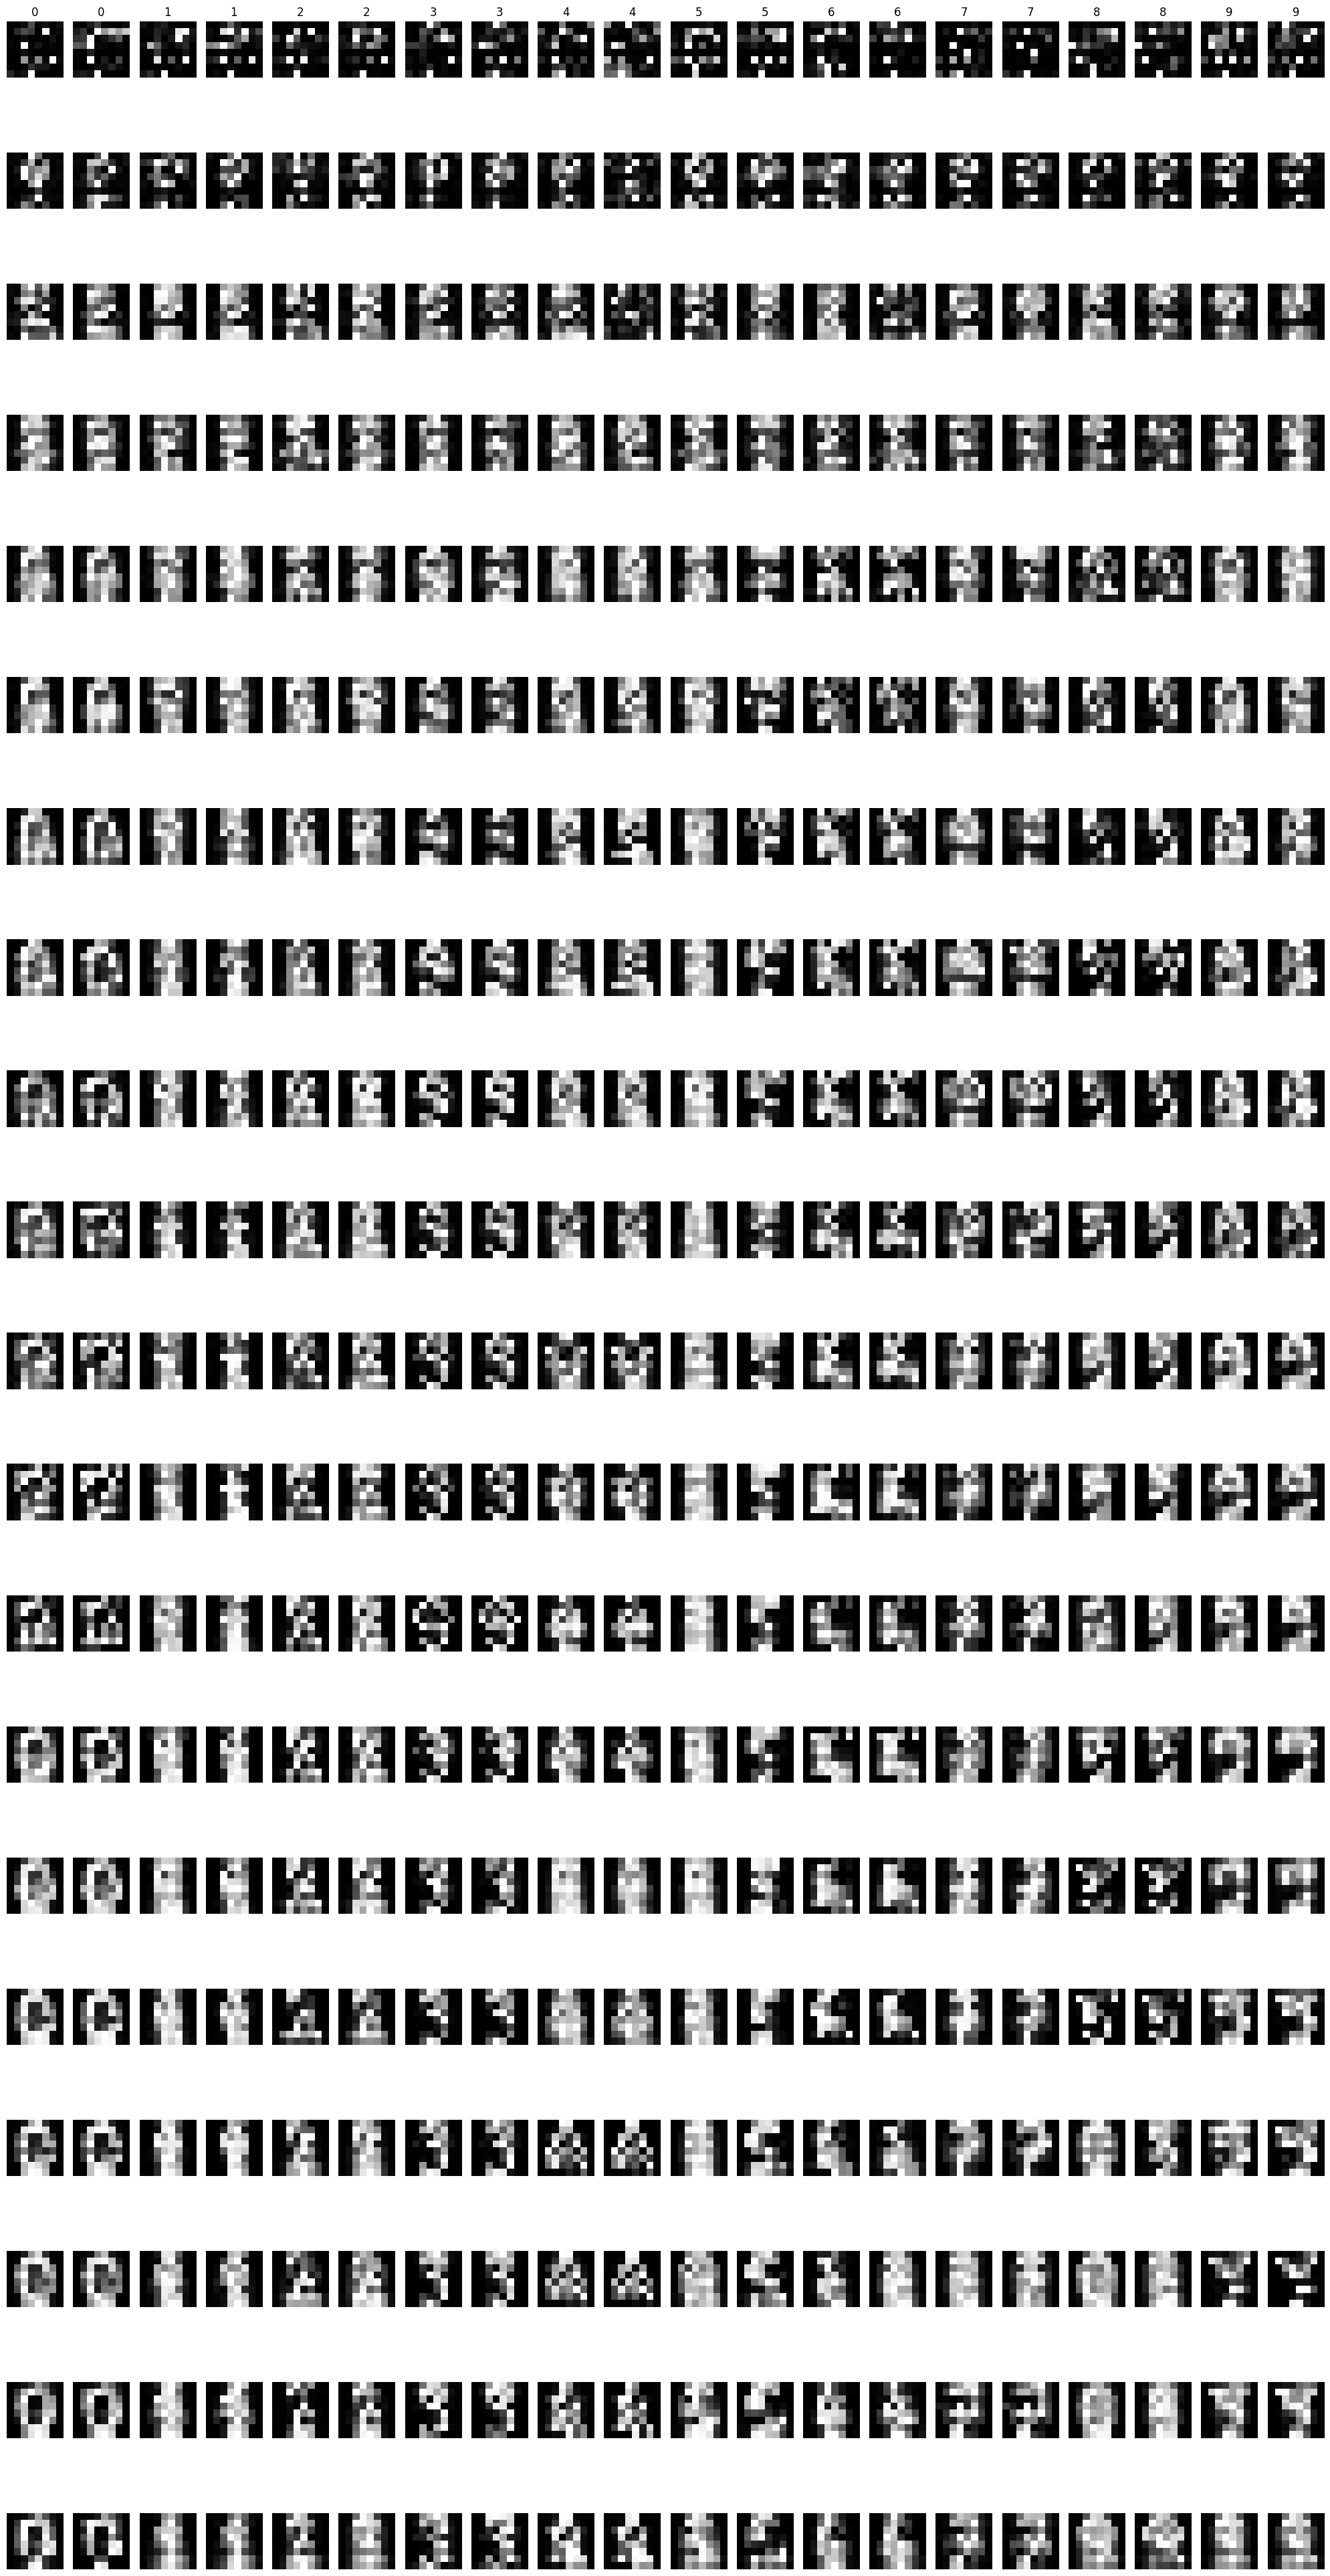

In [16]:
fig, axes = plt.subplots(
    max(1,len(results)),
    20,
    figsize=(20,2*max(1,len(results))),
    squeeze=False
)

for row,images in enumerate(results):

    images = images.squeeze(1)

    for col in range(20):

        axes[row,col].imshow(
            images[col],
            cmap="gray"
        )

        axes[row,col].axis("off")

        if row==0:

            axes[row,col].set_title(
                str(fixed_labels[col].item())
            )

plt.tight_layout()

plt.show()

In [17]:
@torch.no_grad()
def generate_digit(digit, n=8):
    """
    Generate n samples of a chosen digit.
    """
    generator.eval()

    noise = torch.randn(
        n,
        latent_dim,
        device=device
    )

    labels = torch.full(
        (n,),
        digit,
        device=device,
        dtype=torch.long
    )

    images = generator(
        noise,
        labels
    )

    images = images.view(
        n,
        8,
        8
    )

    return images.cpu()

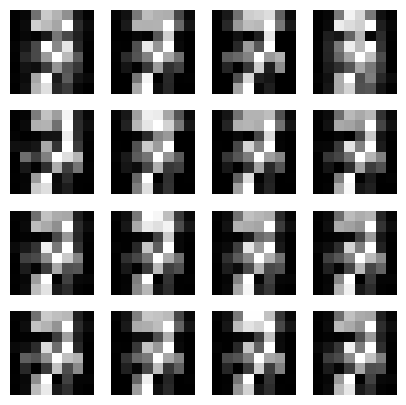

In [18]:
images = generate_digit(7,16)

fig,ax = plt.subplots(4,4,figsize=(5,5))

for i,a in enumerate(ax.flatten()):

    a.imshow(images[i],cmap="gray")

    a.axis("off")

plt.show()

In [19]:
torch.save(
    generator.state_dict(),
    "conditional_qgan_generator.pth"
)

In [20]:
import torchvision

with torch.no_grad():
    imgs = generator(
        fixed_noise,
        fixed_labels
    ).view(20, 1, 8, 8).cpu()

torchvision.utils.save_image(
    imgs,
    "generated_digits.png",
    nrow=10,
    normalize=True
)